# 4.4 — Sampling & Randomness, at the computer

Do the **pen-and-paper worksheet first**. Here you'll measure the wobble of estimates, catch
seeds red-handed, un-sort a dataset, and pull the temperature dial on a toy language model.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 1. Measure the wobble

A fair coin: the truth is 0.5. An estimate from $n$ flips *wobbles* around that truth.
The lesson claimed wobble shrinks like $\frac{1}{\sqrt{n}}$. Let's not take its word for it —
for each sample size, run 2,000 separate estimates and measure how much they scatter:

n =     10:  estimates range 0.100–1.000,  wobble = 0.1603
n =    100:  estimates range 0.330–0.670,  wobble = 0.0506
n =   1000:  estimates range 0.438–0.556,  wobble = 0.0157
n =  10000:  estimates range 0.484–0.515,  wobble = 0.0049


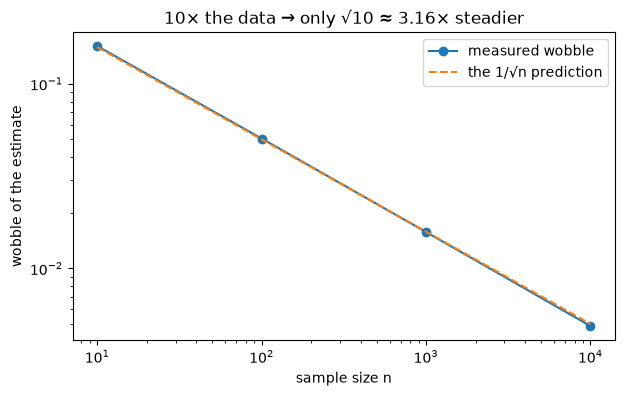

In [2]:
sample_sizes = np.array([10, 100, 1_000, 10_000])
wobbles = []

for n in sample_sizes:
    flips = rng.integers(0, 2, size=(2_000, n))   # 2,000 experiments of n flips each
    estimates = flips.mean(axis=1)                # each row's fraction of heads = one estimate
    wobbles.append(estimates.std())               # scatter of the 2,000 estimates = the wobble
    print(f"n = {n:>6}:  estimates range {estimates.min():.3f}\u2013{estimates.max():.3f},  wobble = {estimates.std():.4f}")

plt.figure(figsize=(7, 4))
plt.loglog(sample_sizes, wobbles, "o-", label="measured wobble")        # loglog: both axes log
plt.loglog(sample_sizes, 0.5 / np.sqrt(sample_sizes), "--", label="the 1/\u221an prediction")
plt.xlabel("sample size n"); plt.ylabel("wobble of the estimate")
plt.title("10\u00d7 the data \u2192 only \u221a10 \u2248 3.16\u00d7 steadier")
plt.legend()
plt.show()

# YOUR TURN — before running: predict the wobble for n = 100,000. Then add it to
# sample_sizes above and re-run. Did √n hold?

The dots land on the dashed line. That's the law that prices data: **accuracy is bought with
squared effort.**

## 2. Randomness you can replay: seeds

"Random" numbers from a computer are generated by an algorithm from a starting value — the
**seed**. Same seed, same universe:

In [3]:
print("seed 42, run 1:", np.random.default_rng(42).integers(1, 7, size=8))
print("seed 42, run 2:", np.random.default_rng(42).integers(1, 7, size=8))   # identical!
print("seed 7,  run 1:", np.random.default_rng(7).integers(1, 7, size=8))    # new universe
print("no seed:       ", np.random.default_rng().integers(1, 7, size=8))     # different EVERY run

# This is why every notebook in this repo opens with default_rng(42): a training run that
# misbehaves at step 40,000 can be replayed EXACTLY. Reproducible randomness = debuggable ML.
# (And it's why your plots match Claude's descriptions of them.)

# YOUR TURN — re-run this cell a few times. Which line changes? Which never do?

seed 42, run 1: [1 5 4 3 3 6 1 5]
seed 42, run 2: [1 5 4 3 3 6 1 5]
seed 7,  run 1: [6 4 5 6 4 5 6 2]
no seed:        [4 3 3 5 6 2 1 3]


## 3. Why training shuffles the data

A minibatch is a *sample* of the dataset — and Part C of the worksheet said it: samples must be
**representative**. Watch what sorted data does to minibatches:

In [4]:
labels = np.array(["cat"] * 8 + ["dog"] * 8)      # a sorted dataset: all cats first
print("sorted dataset: ", labels)
print("  batch 1:", labels[0:4], "\u2190 100% cat — a biased sample!")
print("  batch 2:", labels[4:8], "\u2190 still all cat; the net just learns 'say cat'")

rng.shuffle(labels)                               # shuffles IN PLACE — rearranges labels itself
print("\nshuffled:       ", labels)
print("  batch 1:", labels[0:4], "\u2190 now a fair sample of the whole dataset")
print("  batch 2:", labels[4:8])

# Every epoch of real training starts with exactly this move, on a million-item scale.

sorted dataset:  ['cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog'
 'dog' 'dog' 'dog' 'dog']
  batch 1: ['cat' 'cat' 'cat' 'cat'] ← 100% cat — a biased sample!
  batch 2: ['cat' 'cat' 'cat' 'cat'] ← still all cat; the net just learns 'say cat'

shuffled:        ['dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'dog' 'cat'
 'dog' 'cat' 'cat' 'dog']
  batch 1: ['dog' 'cat' 'cat' 'dog'] ← now a fair sample of the whole dataset
  batch 2: ['cat' 'dog' 'dog' 'cat']


## 4. Sampling with a temperature dial (Module 6 preview)

An LLM ends each step holding a probability for every possible next token. It then **samples**.
Temperature $T$ reshapes the distribution first — sharpen it ($T < 1$) or flatten it ($T > 1$) —
using a move you own from 0.5: raise to the power $\frac{1}{T}$, then re-normalise so it all
sums to 1.

In [5]:
tokens = np.array(["blue", "grey", "green", "purple"])   # "the sky was ___"
probs = np.array([0.5, 0.3, 0.15, 0.05])                  # the model's honest opinion

for T in [0.2, 1.0, 3.0]:
    p = probs ** (1 / T)          # T<1: big probs get bigger. T>1: everything evens out.
    p = p / p.sum()               # re-normalise: probabilities must sum to 1
    # rng.choice picks from `tokens`, using column `p` as the probabilities:
    sample = rng.choice(tokens, size=20, p=p)
    print(f"T = {T}:  p = {p.round(3)}")
    print("        20 samples:", " ".join(sample), "\n")

# YOUR TURN
# a) Try T = 0.01 and T = 10. Describe each in one word.
# b) Which T for drafting a legal contract? Which for brainstorming poem lines?
# c) At T = 1.0, roughly how many of 20 samples should be "blue"? Count them. Then re-run the
#    cell — the count wobbles. Which section of this notebook explains why 20 is a wobbly n?

T = 0.2:  p = [0.926 0.072 0.002 0.   ]
        20 samples: blue blue blue blue blue blue blue blue blue blue blue blue blue blue grey blue blue blue blue blue 

T = 1.0:  p = [0.5  0.3  0.15 0.05]
        20 samples: blue grey purple green purple blue blue green blue blue grey grey blue blue grey grey green grey blue grey 

T = 3.0:  p = [0.336 0.283 0.225 0.156]
        20 samples: blue blue blue blue green blue grey green green green green grey grey grey grey grey blue blue purple grey 



## 5. What you now own

Training a neural net is: **shuffle** (fair minibatches) → estimate gradients from **samples**
(wobbly, steadied by $\sqrt{n}$) → starting from **seeded** random weights (replayable) — and
generation is **sampling with a temperature dial**. The randomness in ML isn't sloppiness;
every piece is doing a job you can now name.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude. Next: 4.5 — the last piece:
why the loss function of every classifier on Earth is a log in disguise.*